## Problem 1 Overview

This notebook completes the modified AlexNet experiment for CIFAR-10. The code adapts AlexNet for 32x32 images, trains a baseline model, trains dropout variants at p = 0.3 and p = 0.5, and compares the resulting validation and test performance.


### Mount Google Drive

This cell connects Google Drive to Colab. The notebook saves checkpoints, result CSV files, and figures into Drive so outputs remain available after the runtime disconnects.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Imports, Reproducibility, and Output Folders

This cell imports the Python, PyTorch, torchvision, plotting, and file utilities needed for the experiment. It sets the random seed to 42, selects CUDA when available, and creates the output folders used for saved figures and model checkpoints.


In [ ]:
import os
import time
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, Dataset
from PIL import Image

seed = 42
batch_size = 128
learning_rate = 0.001
alexnet_epochs = 30
num_classes = 10

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

OUTPUT_DIR = Path("/content/drive/MyDrive/ECGR4106_HW1/problem1")
FIG_DIR = OUTPUT_DIR / "figures"
CKPT_DIR = OUTPUT_DIR / "checkpoints"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)
print("Saving outputs to:", OUTPUT_DIR)

Using device: cuda
Saving outputs to: /content/drive/MyDrive/ECGR4106_HW1/problem1


### CIFAR-10 Dataset and DataLoaders

This cell defines CIFAR-10 normalization, training augmentation, validation/test transforms, and the fixed 45,000/5,000/10,000 train-validation-test split. It also includes fallback dataset loading logic for Colab download errors.


In [ ]:
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]


class CIFAR10FromArrays(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx])
        label = int(self.labels[idx])
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def load_cifar10_from_fastai_mirror():
    """Download CIFAR-10 from fast.ai's public mirror and load it with ImageFolder."""
    import tarfile
    import urllib.request

    data_root = Path("./data")
    archive_path = data_root / "fastai-cifar10.tgz"
    extracted_root = data_root / "cifar10"
    url = "https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz"

    data_root.mkdir(parents=True, exist_ok=True)

    if not extracted_root.exists():
        print("Downloading CIFAR-10 from fast.ai mirror...")
        urllib.request.urlretrieve(url, archive_path)
        print("Extracting CIFAR-10 archive...")
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(data_root)

    train_dir = extracted_root / "train"
    test_dir = extracted_root / "test"

    train_base = torchvision.datasets.ImageFolder(train_dir, transform=train_transform)
    val_base = torchvision.datasets.ImageFolder(train_dir, transform=eval_transform)
    test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=eval_transform)

    print("Loaded CIFAR-10 with fast.ai mirror + PyTorch ImageFolder.")
    return train_base, val_base, test_dataset


def load_cifar10_datasets():
    try:
        print("Trying torchvision CIFAR-10 download...")
        train_base = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=train_transform)
        val_base = torchvision.datasets.CIFAR10("./data", train=True, download=False, transform=eval_transform)
        test_dataset = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=eval_transform)
        print("Loaded CIFAR-10 with torchvision.")
        return train_base, val_base, test_dataset
    except Exception as error:
        print("torchvision download failed:", repr(error))

    try:
        print("Trying tensorflow.keras CIFAR-10 loader...")
        import tensorflow as tf
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
        y_train = y_train.flatten()
        y_test = y_test.flatten()
        train_base = CIFAR10FromArrays(x_train, y_train, transform=train_transform)
        val_base = CIFAR10FromArrays(x_train, y_train, transform=eval_transform)
        test_dataset = CIFAR10FromArrays(x_test, y_test, transform=eval_transform)
        print("Loaded CIFAR-10 with tensorflow.keras arrays.")
        return train_base, val_base, test_dataset
    except Exception as error:
        print("tensorflow.keras download failed:", repr(error))

    print("Trying fast.ai public mirror...")
    return load_cifar10_from_fastai_mirror()


train_base, val_base, test_dataset = load_cifar10_datasets()

generator = torch.Generator().manual_seed(seed)
indices = torch.randperm(len(train_base), generator=generator).tolist()
train_indices = indices[:45000]
val_indices = indices[45000:]

train_dataset = Subset(train_base, train_indices)
val_dataset = Subset(val_base, val_indices)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=(device == "cuda"))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=(device == "cuda"))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=(device == "cuda"))

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Classes:", classes)

Trying torchvision CIFAR-10 download...
torchvision download failed: <HTTPError 403: 'Forbidden'>
Trying tensorflow.keras CIFAR-10 loader...
tensorflow.keras download failed: Exception('URL fetch failure on https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz: 403 -- Forbidden')
Trying fast.ai public mirror...
Extracting CIFAR-10 archive...


/tmp/ipykernel_1402/2463344247.py:56: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_root)


Loaded CIFAR-10 with fast.ai mirror + PyTorch ImageFolder.
Training images: 45000
Validation images: 5000
Test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Training and Plotting Helpers

This cell defines reusable functions for parameter counting, one-epoch training, evaluation, checkpoint saving, training history logging, curve plotting, and confusion matrix plotting. These helpers keep all AlexNet variants evaluated consistently.


In [ ]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, total_correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(1)
        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, total_correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model, run_name, epochs=30, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_val_acc = -1
    best_path = CKPT_DIR / f"{run_name}_best.pth"
    history = []
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()
        epoch_time = time.time() - epoch_start

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": epoch_time,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)

        print(f"{run_name} | epoch {epoch:02d}/{epochs} | train loss {train_loss:.4f} | train acc {train_acc:.4f} | val loss {val_loss:.4f} | val acc {val_acc:.4f} | {epoch_time:.1f}s")

    total_time = time.time() - start_time
    history_df = pd.DataFrame(history)
    history_df.to_csv(OUTPUT_DIR / f"{run_name}_history.csv", index=False)

    model.load_state_dict(torch.load(best_path, map_location=device))
    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

    summary = {
        "run_name": run_name,
        "epochs": epochs,
        "learning_rate": lr,
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "batch_size": batch_size,
        "seed": seed,
        "parameter_count": count_trainable_parameters(model),
        "best_val_accuracy": float(history_df["val_accuracy"].max()),
        "test_loss": float(test_loss),
        "final_test_accuracy": float(test_acc),
        "total_training_time_sec": float(total_time),
        "mean_epoch_time_sec": float(history_df["epoch_time_sec"].mean()),
    }

    with open(OUTPUT_DIR / f"{run_name}_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    return model, history_df, {"loss": test_loss, "accuracy": test_acc, "preds": test_preds, "labels": test_labels}, summary


def plot_history(history_df, run_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{run_name}: Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="Validation accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{run_name}: Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = FIG_DIR / f"{run_name}_curves.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)


def plot_confusion_matrix(labels, preds, run_name):
    matrix = np.zeros((len(classes), len(classes)), dtype=int)
    for true_label, pred_label in zip(labels, preds):
        matrix[true_label, pred_label] += 1

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_title(f"{run_name}: Confusion Matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)

    for i in range(len(classes)):
        for j in range(len(classes)):
            color = "white" if matrix[i, j] > matrix.max() * 0.55 else "black"
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center", color=color, fontsize=8)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    save_path = FIG_DIR / f"{run_name}_confusion_matrix.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)


def compare_histories(histories, metric, title, ylabel, filename):
    plt.figure(figsize=(8, 5))
    for run_name, history_df in histories.items():
        plt.plot(history_df["epoch"], history_df[metric], label=run_name)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_path = FIG_DIR / filename
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

### Modified AlexNet Definition

This cell defines the CIFAR-10 version of AlexNet. The model uses smaller 3x3 convolutions, three max-pooling layers, and a compact classifier so the architecture fits 32x32 images without collapsing spatial dimensions too early.


In [ ]:
class ModifiedAlexNet(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        classifier = [
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
        ]
        if dropout_p > 0:
            classifier.append(nn.Dropout(p=dropout_p))
        classifier += [
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
        ]
        if dropout_p > 0:
            classifier.append(nn.Dropout(p=dropout_p))
        classifier.append(nn.Linear(256, num_classes))
        self.classifier = nn.Sequential(*classifier)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


test_model = ModifiedAlexNet(dropout_p=0.0)
print(test_model)
print("Modified AlexNet trainable parameters:", count_trainable_parameters(test_model))
print("Original AlexNet parameters: about 61,000,000")

ModifiedAlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=512, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(

### First-Layer Filter Visualization Helper

This cell defines a visualization function for the first convolutional layer. The filters are normalized for display so learned color and edge-like patterns can be inspected in the report.


In [ ]:
def visualize_first_layer_filters(model, run_name):
    weights = model.features[0].weight.detach().cpu()
    weights = weights - weights.amin(dim=(1, 2, 3), keepdim=True)
    weights = weights / (weights.amax(dim=(1, 2, 3), keepdim=True) + 1e-8)

    n = min(64, weights.shape[0])
    fig, axes = plt.subplots(8, 8, figsize=(9, 9))
    axes = axes.flatten()

    for i in range(n):
        axes[i].imshow(weights[i].permute(1, 2, 0).numpy())
        axes[i].axis("off")
    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.suptitle(f"{run_name}: First Convolutional Layer Filters")
    plt.tight_layout()
    save_path = FIG_DIR / f"{run_name}_conv1_filters.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

### Train AlexNet Baseline

This cell trains the modified AlexNet without dropout for 30 epochs. The baseline is the reference model for determining whether dropout improves or hurts generalization.


In [ ]:
alexnet_baseline = ModifiedAlexNet(num_classes=num_classes, dropout_p=0.0)
alexnet_baseline, hist_baseline, test_baseline, summary_baseline = train_model(
    alexnet_baseline,
    run_name="alexnet_baseline",
    epochs=alexnet_epochs,
    lr=learning_rate,
)
summary_baseline

alexnet_baseline | epoch 01/30 | train loss 1.7414 | train acc 0.3449 | val loss 1.4386 | val acc 0.4648 | 28.8s
alexnet_baseline | epoch 02/30 | train loss 1.2994 | train acc 0.5211 | val loss 1.1417 | val acc 0.5876 | 28.1s
alexnet_baseline | epoch 03/30 | train loss 1.0928 | train acc 0.6074 | val loss 1.0366 | val acc 0.6408 | 28.3s
alexnet_baseline | epoch 04/30 | train loss 0.9363 | train acc 0.6632 | val loss 0.8694 | val acc 0.6960 | 26.6s
alexnet_baseline | epoch 05/30 | train loss 0.8181 | train acc 0.7116 | val loss 0.7803 | val acc 0.7252 | 27.1s
alexnet_baseline | epoch 06/30 | train loss 0.7500 | train acc 0.7374 | val loss 0.7227 | val acc 0.7516 | 27.6s
alexnet_baseline | epoch 07/30 | train loss 0.6773 | train acc 0.7624 | val loss 0.7003 | val acc 0.7676 | 27.7s
alexnet_baseline | epoch 08/30 | train loss 0.6291 | train acc 0.7788 | val loss 0.7213 | val acc 0.7582 | 27.7s
alexnet_baseline | epoch 09/30 | train loss 0.5724 | train acc 0.8003 | val loss 0.6463 | val ac

{'run_name': 'alexnet_baseline',
 'epochs': 30,
 'learning_rate': 0.001,
 'optimizer': 'Adam',
 'scheduler': 'CosineAnnealingLR',
 'batch_size': 128,
 'seed': 42,
 'parameter_count': 4483146,
 'best_val_accuracy': 0.8498,
 'test_loss': 0.5285977302551269,
 'final_test_accuracy': 0.8477,
 'total_training_time_sec': 826.7564470767975,
 'mean_epoch_time_sec': 27.52076059182485}

### Plot AlexNet Baseline Results

This cell plots the baseline training curves, creates the test-set confusion matrix, and visualizes the first convolutional filters. These outputs satisfy the required plots and filter visualization for Problem 1A.


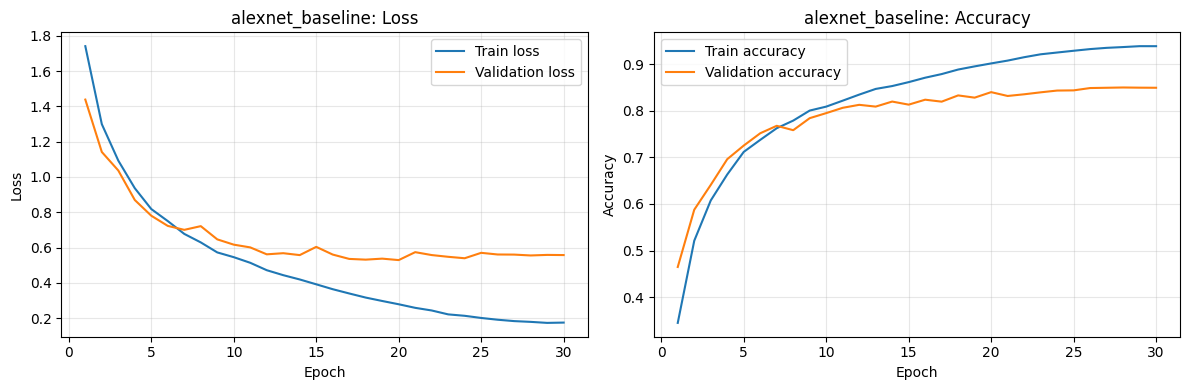

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem1/figures/alexnet_baseline_curves.png


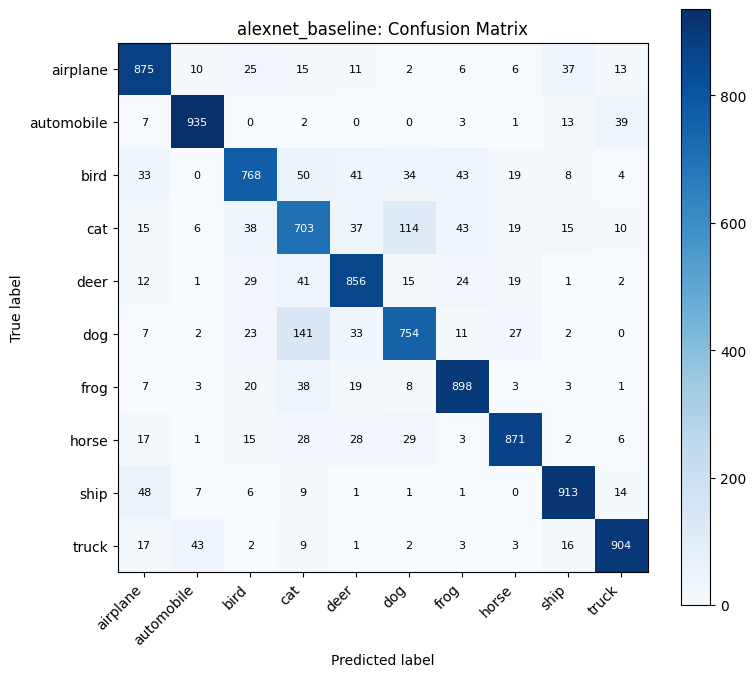

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem1/figures/alexnet_baseline_confusion_matrix.png


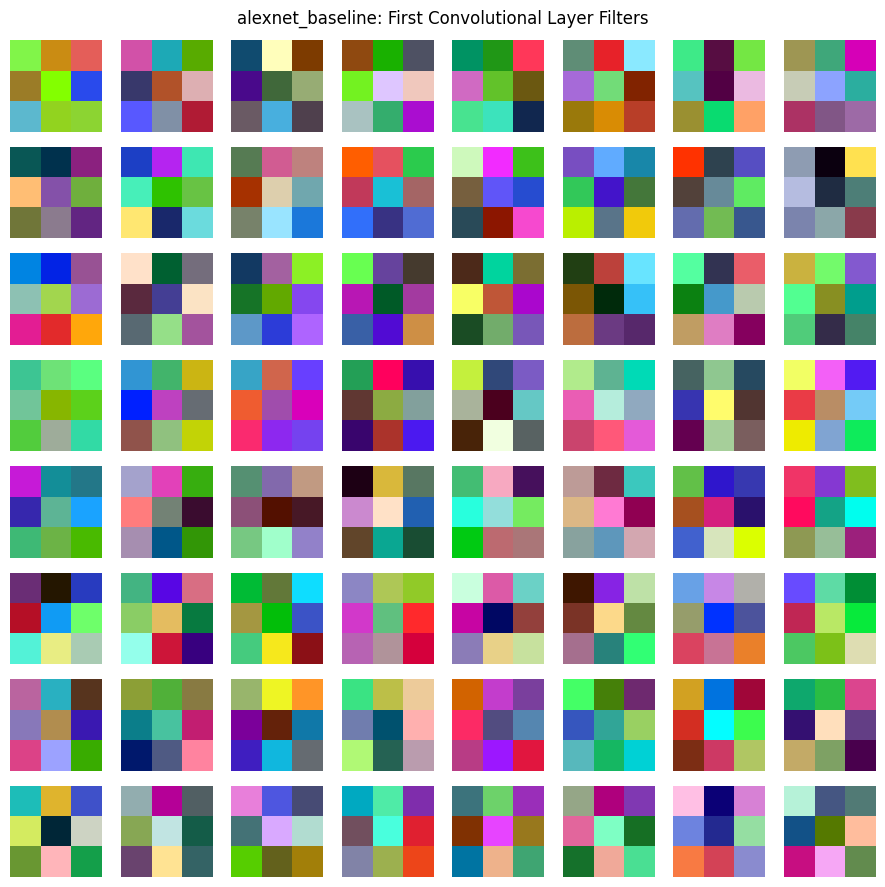

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem1/figures/alexnet_baseline_conv1_filters.png


In [ ]:
plot_history(hist_baseline, "alexnet_baseline")
plot_confusion_matrix(test_baseline["labels"], test_baseline["preds"], "alexnet_baseline")
visualize_first_layer_filters(alexnet_baseline, "alexnet_baseline")

### Train AlexNet with Dropout p = 0.3

This cell trains the same AlexNet architecture with dropout p = 0.3 in the classifier. Keeping the same hyperparameters isolates the effect of dropout.


In [ ]:
alexnet_dropout_03 = ModifiedAlexNet(num_classes=num_classes, dropout_p=0.3)
alexnet_dropout_03, hist_dropout_03, test_dropout_03, summary_dropout_03 = train_model(
    alexnet_dropout_03,
    run_name="alexnet_dropout_03",
    epochs=alexnet_epochs,
    lr=learning_rate,
)
summary_dropout_03

alexnet_dropout_03 | epoch 01/30 | train loss 1.8063 | train acc 0.3078 | val loss 1.4755 | val acc 0.4488 | 27.9s
alexnet_dropout_03 | epoch 02/30 | train loss 1.4220 | train acc 0.4746 | val loss 1.2612 | val acc 0.5376 | 27.2s
alexnet_dropout_03 | epoch 03/30 | train loss 1.2450 | train acc 0.5498 | val loss 1.0943 | val acc 0.6068 | 25.0s
alexnet_dropout_03 | epoch 04/30 | train loss 1.0973 | train acc 0.6107 | val loss 0.9738 | val acc 0.6552 | 26.6s
alexnet_dropout_03 | epoch 05/30 | train loss 0.9840 | train acc 0.6553 | val loss 0.8850 | val acc 0.6812 | 26.2s
alexnet_dropout_03 | epoch 06/30 | train loss 0.9061 | train acc 0.6852 | val loss 0.8107 | val acc 0.7150 | 26.4s
alexnet_dropout_03 | epoch 07/30 | train loss 0.8330 | train acc 0.7089 | val loss 0.8029 | val acc 0.7224 | 26.1s
alexnet_dropout_03 | epoch 08/30 | train loss 0.7797 | train acc 0.7317 | val loss 0.7313 | val acc 0.7444 | 25.2s
alexnet_dropout_03 | epoch 09/30 | train loss 0.7232 | train acc 0.7508 | val lo

{'run_name': 'alexnet_dropout_03',
 'epochs': 30,
 'learning_rate': 0.001,
 'optimizer': 'Adam',
 'scheduler': 'CosineAnnealingLR',
 'batch_size': 128,
 'seed': 42,
 'parameter_count': 4483146,
 'best_val_accuracy': 0.8344,
 'test_loss': 0.5408172438144684,
 'final_test_accuracy': 0.8265,
 'total_training_time_sec': 776.8936898708344,
 'mean_epoch_time_sec': 25.857853666941324}

### Plot AlexNet Dropout p = 0.3 Results

This cell creates the loss/accuracy curves and confusion matrix for the p = 0.3 dropout model so its behavior can be compared against the baseline.


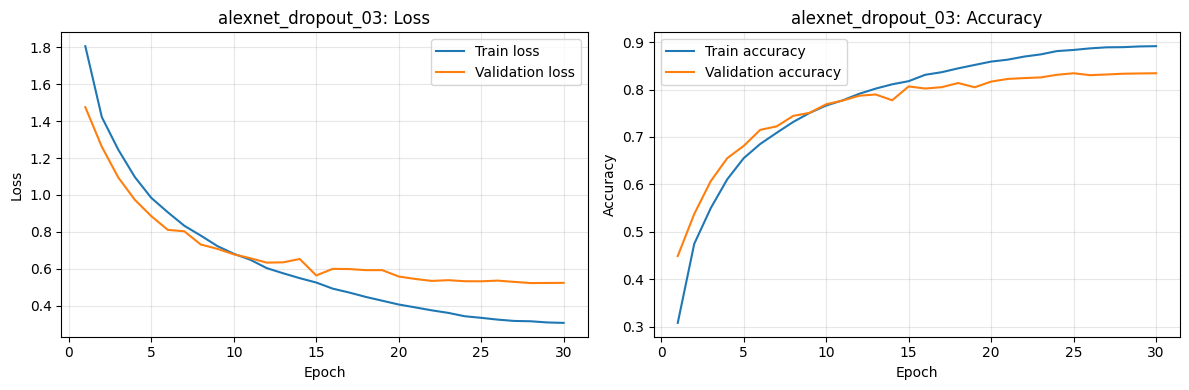

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem1/figures/alexnet_dropout_03_curves.png


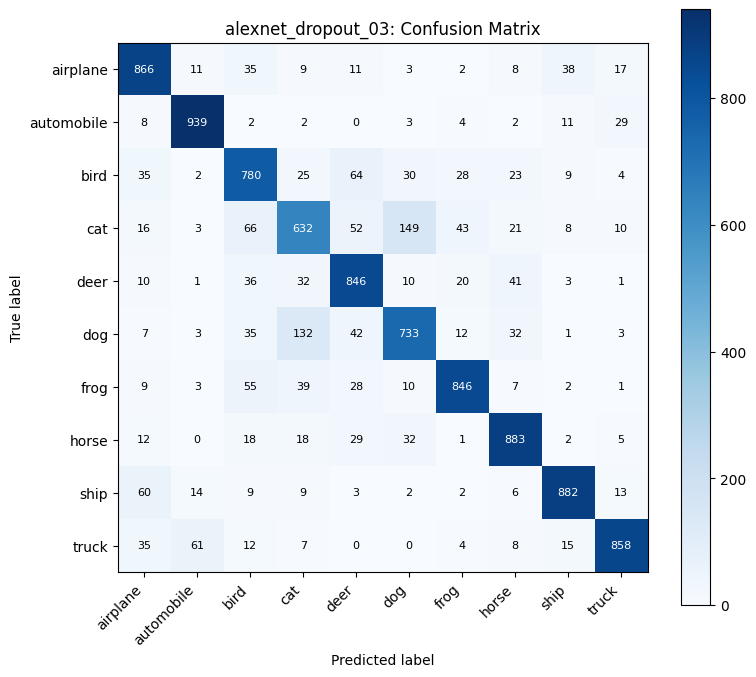

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem1/figures/alexnet_dropout_03_confusion_matrix.png


In [ ]:
plot_history(hist_dropout_03, "alexnet_dropout_03")
plot_confusion_matrix(test_dropout_03["labels"], test_dropout_03["preds"], "alexnet_dropout_03")

### Train AlexNet with Dropout p = 0.5

This cell trains the same AlexNet architecture with stronger dropout p = 0.5. This tests whether more aggressive regularization improves validation and test performance.


In [ ]:
alexnet_dropout_05 = ModifiedAlexNet(num_classes=num_classes, dropout_p=0.5)
alexnet_dropout_05, hist_dropout_05, test_dropout_05, summary_dropout_05 = train_model(
    alexnet_dropout_05,
    run_name="alexnet_dropout_05",
    epochs=alexnet_epochs,
    lr=learning_rate,
)
summary_dropout_05

alexnet_dropout_05 | epoch 01/30 | train loss 1.8279 | train acc 0.3016 | val loss 1.5081 | val acc 0.4450 | 24.4s
alexnet_dropout_05 | epoch 02/30 | train loss 1.4135 | train acc 0.4816 | val loss 1.2268 | val acc 0.5470 | 25.7s
alexnet_dropout_05 | epoch 03/30 | train loss 1.2107 | train acc 0.5694 | val loss 1.0756 | val acc 0.6136 | 26.0s
alexnet_dropout_05 | epoch 04/30 | train loss 1.0622 | train acc 0.6289 | val loss 0.9133 | val acc 0.6770 | 25.8s
alexnet_dropout_05 | epoch 05/30 | train loss 0.9461 | train acc 0.6741 | val loss 0.8539 | val acc 0.7018 | 24.4s
alexnet_dropout_05 | epoch 06/30 | train loss 0.8669 | train acc 0.7011 | val loss 0.7871 | val acc 0.7252 | 25.8s
alexnet_dropout_05 | epoch 07/30 | train loss 0.7910 | train acc 0.7284 | val loss 0.7349 | val acc 0.7524 | 25.8s
alexnet_dropout_05 | epoch 08/30 | train loss 0.7392 | train acc 0.7488 | val loss 0.7015 | val acc 0.7606 | 26.2s
alexnet_dropout_05 | epoch 09/30 | train loss 0.6905 | train acc 0.7644 | val lo

{'run_name': 'alexnet_dropout_05',
 'epochs': 30,
 'learning_rate': 0.001,
 'optimizer': 'Adam',
 'scheduler': 'CosineAnnealingLR',
 'batch_size': 128,
 'seed': 42,
 'parameter_count': 4483146,
 'best_val_accuracy': 0.8466,
 'test_loss': 0.5185632641136646,
 'final_test_accuracy': 0.8446,
 'total_training_time_sec': 796.8261408805847,
 'mean_epoch_time_sec': 26.517589767773945}

### Plot AlexNet Dropout p = 0.5 Results

This cell creates the loss/accuracy curves and confusion matrix for the p = 0.5 dropout model.


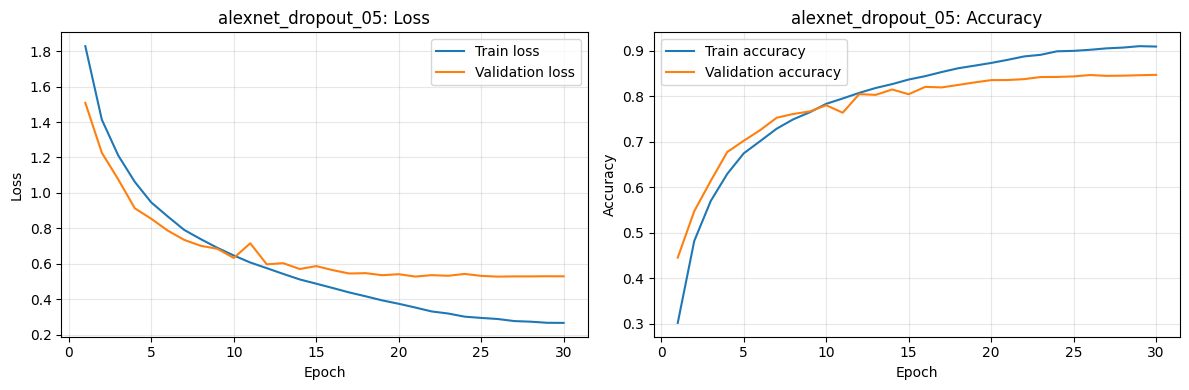

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem1/figures/alexnet_dropout_05_curves.png


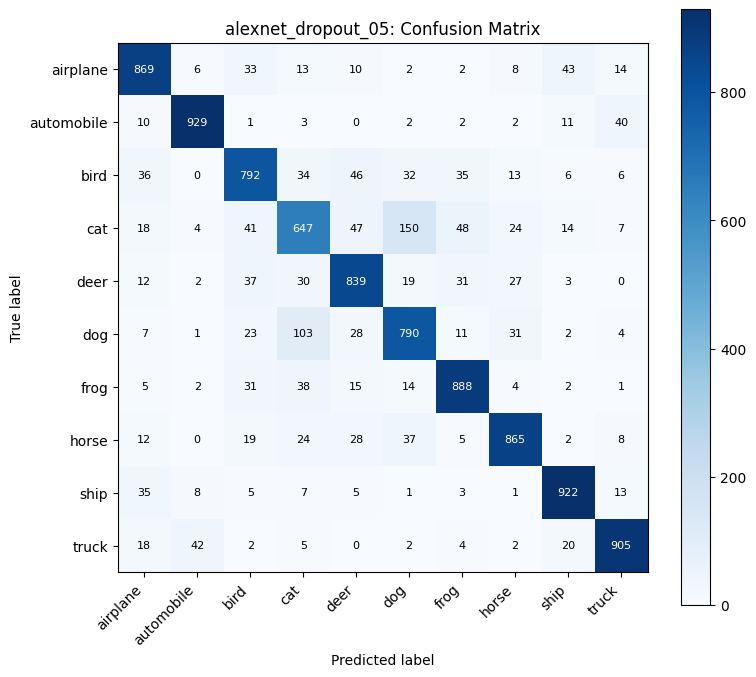

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem1/figures/alexnet_dropout_05_confusion_matrix.png


In [ ]:
plot_history(hist_dropout_05, "alexnet_dropout_05")
plot_confusion_matrix(test_dropout_05["labels"], test_dropout_05["preds"], "alexnet_dropout_05")

### Compare AlexNet Variants

This cell compares the baseline, dropout p = 0.3, and dropout p = 0.5 histories. It also creates the summary table used in the report.


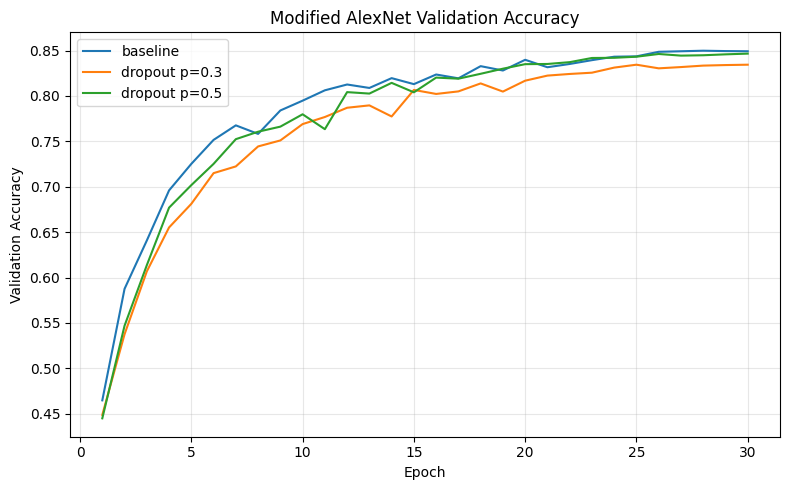

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem1/figures/alexnet_val_accuracy_comparison.png


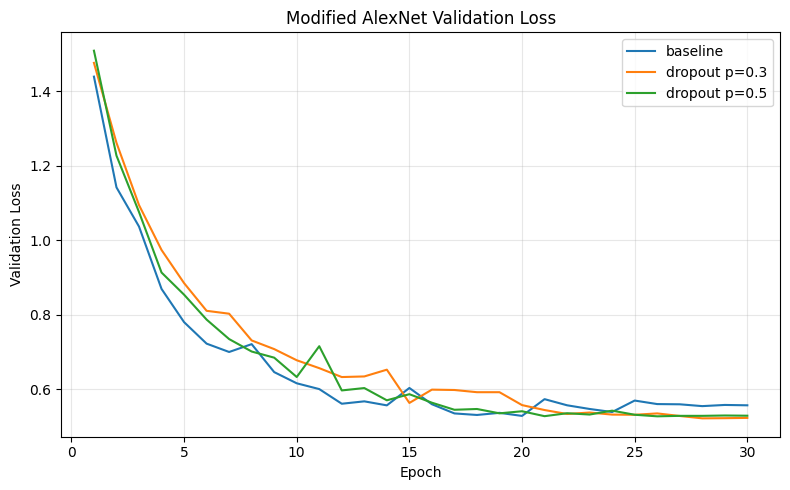

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem1/figures/alexnet_val_loss_comparison.png


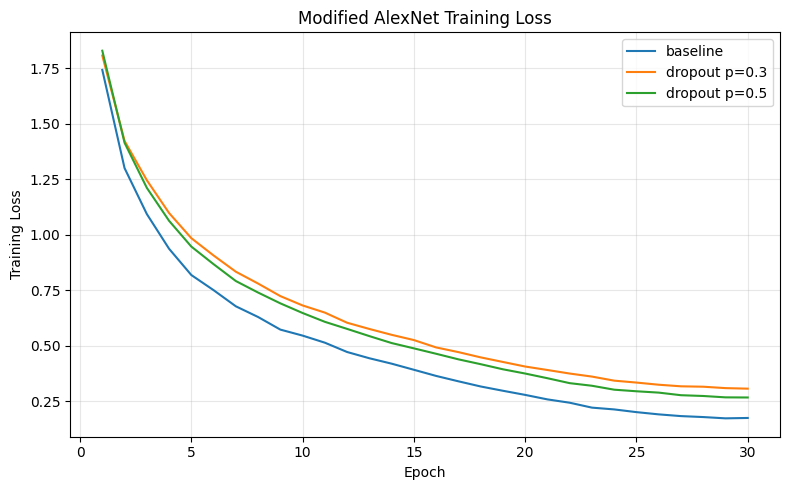

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem1/figures/alexnet_train_loss_comparison.png


,run_name,dropout,parameter_count,best_val_accuracy,final_test_accuracy,mean_epoch_time_sec,total_training_time_sec,optimizer,learning_rate,scheduler,batch_size,seed
0,alexnet_baseline,none,4483146,0.8498,0.8477,27.520761,826.756447,Adam,0.001,CosineAnnealingLR,128,42
1,alexnet_dropout_03,0.3,4483146,0.8344,0.8265,25.857854,776.893690,Adam,0.001,CosineAnnealingLR,128,42
2,alexnet_dropout_05,0.5,4483146,0.8466,0.8446,26.517590,796.826141,Adam,0.001,CosineAnnealingLR,128,42


In [ ]:
histories = {
    "baseline": hist_baseline,
    "dropout p=0.3": hist_dropout_03,
    "dropout p=0.5": hist_dropout_05,
}

compare_histories(histories, "val_accuracy", "Modified AlexNet Validation Accuracy", "Validation Accuracy", "alexnet_val_accuracy_comparison.png")
compare_histories(histories, "val_loss", "Modified AlexNet Validation Loss", "Validation Loss", "alexnet_val_loss_comparison.png")
compare_histories(histories, "train_loss", "Modified AlexNet Training Loss", "Training Loss", "alexnet_train_loss_comparison.png")

results_df = pd.DataFrame([summary_baseline, summary_dropout_03, summary_dropout_05])
results_df["dropout"] = ["none", "0.3", "0.5"]
results_df = results_df[[
    "run_name",
    "dropout",
    "parameter_count",
    "best_val_accuracy",
    "final_test_accuracy",
    "mean_epoch_time_sec",
    "total_training_time_sec",
    "optimizer",
    "learning_rate",
    "scheduler",
    "batch_size",
    "seed",
]]
results_df.to_csv(OUTPUT_DIR / "problem1_alexnet_results.csv", index=False)
results_df

### AlexNet Test Accuracy Bar Chart

This cell creates a bar chart of final test accuracy for each AlexNet variant. The baseline is the best AlexNet run in the recorded output.


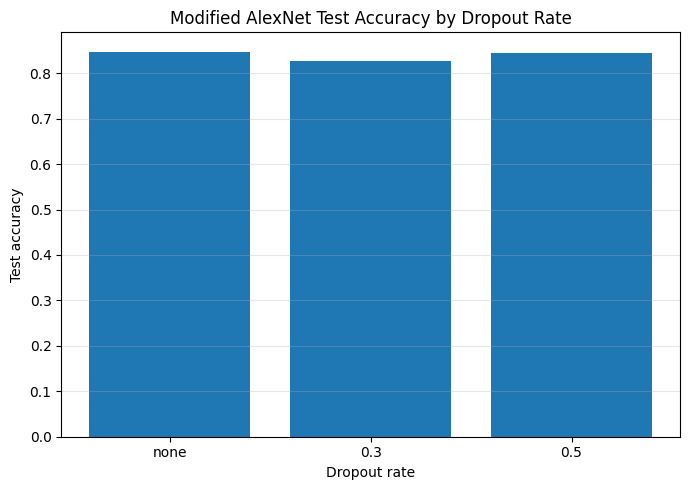

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem1/figures/alexnet_test_accuracy_bar_chart.png


In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(results_df["dropout"], results_df["final_test_accuracy"])
plt.xlabel("Dropout rate")
plt.ylabel("Test accuracy")
plt.title("Modified AlexNet Test Accuracy by Dropout Rate")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_path = FIG_DIR / "alexnet_test_accuracy_bar_chart.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", save_path)